In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import shap

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

In [71]:
data = pd.read_csv("loan_data.csv")   # change name if needed
print(data.shape)
data.head()

(45000, 14)


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [72]:
data = data.drop(columns=["loan_int_rate"], errors="ignore")

In [73]:
print(data.columns)

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score',
       'previous_loan_defaults_on_file', 'loan_status'],
      dtype='object')


In [74]:
data["dti_ratio"] = data["loan_amnt"] / data["person_income"]

In [75]:
data["dti_ratio"] = data["dti_ratio"].clip(upper=2)
data.head()


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status,dti_ratio
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,0.49,3.0,561,No,1,0.486462
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,0.08,2.0,504,Yes,0,0.081420
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,0.44,3.0,635,No,1,0.442193
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,0.44,2.0,675,No,1,0.438855
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,0.53,4.0,586,No,1,0.529221


In [76]:
# Fill numeric columns only
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    data[col] = data[col].fillna(data[col].median())

# Check
print(data.isnull().sum())

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dti_ratio                         0
dtype: int64


In [77]:

classification_features = [
    "dti_ratio",
    "credit_score",
    "person_income",
    "person_emp_exp",
    "person_home_ownership",
    "person_age"
]

X = data[classification_features]
y = data["loan_status"]

In [78]:
# Convert categorical features to numeric

data["person_home_ownership"] = data["person_home_ownership"].map({
    "RENT": 0,
    "OWN": 1,
    "MORTGAGE": 2,
    "OTHER": 3
})

In [79]:
data["person_gender"] = data["person_gender"].str.upper()
data["loan_intent"] = data["loan_intent"].str.upper()
data["previous_loan_defaults_on_file"] = data["previous_loan_defaults_on_file"].str.upper()
data["person_gender"] = data["person_gender"].map({
    "MALE": 1,
    "FEMALE": 0
})


data["previous_loan_defaults_on_file"] = data["previous_loan_defaults_on_file"].map({
    "YES": 1,
    "NO": 0
})

In [80]:
data["person_education"] = data["person_education"].astype("category").cat.codes
data["loan_intent"] = data["loan_intent"].astype("category").cat.codes

In [81]:
data=data.astype("float64")
X = data[classification_features]
y = data["loan_status"]
print(data.dtypes)


person_age                        float64
person_gender                     float64
person_education                  float64
person_income                     float64
person_emp_exp                    float64
person_home_ownership             float64
loan_amnt                         float64
loan_intent                       float64
loan_percent_income               float64
cb_person_cred_hist_length        float64
credit_score                      float64
previous_loan_defaults_on_file    float64
loan_status                       float64
dti_ratio                         float64
dtype: object


In [82]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# alias used by later SHAP cells
X_test_data = X_test.copy()


Before SMOTE:
loan_status
0.0    28000
1.0     8000
Name: count, dtype: int64


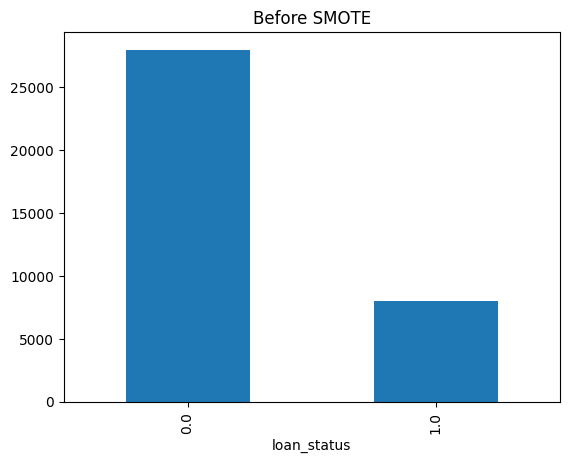

In [83]:
print("Before SMOTE:")
print(y_train.value_counts())

y_train.value_counts().plot(kind='bar', title='Before SMOTE')
plt.show()

In [84]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

After SMOTE:
loan_status
0.0    28000
1.0    28000
Name: count, dtype: int64


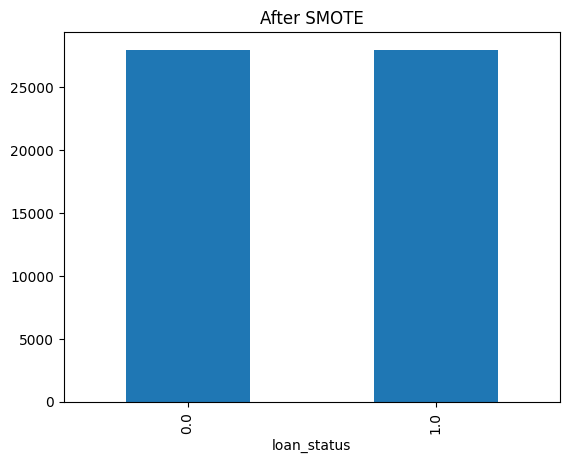

In [85]:
print("After SMOTE:")
print(pd.Series(y_train_smote).value_counts())

pd.Series(y_train_smote).value_counts().plot(
    kind='bar', title='After SMOTE'
)
plt.show()

In [86]:
print(X_train_smote.shape)
print(y_train_smote.shape)

(56000, 6)
(56000,)


In [87]:
epsilon = 1.5        # Privacy budget (recommended)
sensitivity = 1.0   # Assumed sensitivity

In [88]:
np.random.seed(42)

laplace_noise = np.random.laplace(
    loc=0,
    scale=sensitivity / epsilon,
    size=X_train_smote.shape
)

X_train_dp = X_train_smote + laplace_noise


In [89]:
print("Original feature sample:")
print(X_train_smote.iloc[0])

print("\nAfter DP feature sample:")
print(X_train_dp.iloc[0])


Original feature sample:
dti_ratio                    0.074685
credit_score               656.000000
person_income            58914.000000
person_emp_exp               2.000000
person_home_ownership        1.000000
person_age                  24.000000
Name: 0, dtype: float64

After DP feature sample:
dti_ratio                   -0.117921
credit_score               657.544650
person_income            58914.415732
person_emp_exp               2.146530
person_home_ownership        0.223578
person_age                  23.223475
Name: 0, dtype: float64


In [90]:
X_train_dp = pd.DataFrame(
    X_train_dp,
    columns=X_train_smote.columns
)


In [91]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(
    n_estimators=600,
    max_depth=14,
    min_samples_split=4,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42
)

clf.fit(X_train_smote, y_train_smote)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",600
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",14
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",4
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [92]:
print("classification_features" in globals())

True


In [93]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8446666666666667
              precision    recall  f1-score   support

         0.0       0.87      0.94      0.90      7000
         1.0       0.70      0.52      0.60      2000

    accuracy                           0.84      9000
   macro avg       0.79      0.73      0.75      9000
weighted avg       0.83      0.84      0.84      9000



In [94]:
y_probs = clf.predict_proba(X_test)[:, 1]

In [95]:
import numpy as np
from sklearn.metrics import classification_report

for t in [0.4, 0.45, 0.5, 0.55, 0.6]:
    y_pred_t = (y_probs >= t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred_t))


Threshold: 0.4
              precision    recall  f1-score   support

         0.0       0.88      0.87      0.88      7000
         1.0       0.57      0.60      0.58      2000

    accuracy                           0.81      9000
   macro avg       0.73      0.73      0.73      9000
weighted avg       0.81      0.81      0.81      9000


Threshold: 0.45
              precision    recall  f1-score   support

         0.0       0.88      0.91      0.89      7000
         1.0       0.64      0.55      0.59      2000

    accuracy                           0.83      9000
   macro avg       0.76      0.73      0.74      9000
weighted avg       0.82      0.83      0.83      9000


Threshold: 0.5
              precision    recall  f1-score   support

         0.0       0.87      0.94      0.90      7000
         1.0       0.70      0.52      0.60      2000

    accuracy                           0.84      9000
   macro avg       0.79      0.73      0.75      9000
weighted avg       0.83  

In [96]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8446666666666667

Classification Report:

              precision    recall  f1-score   support

         0.0       0.87      0.94      0.90      7000
         1.0       0.70      0.52      0.60      2000

    accuracy                           0.84      9000
   macro avg       0.79      0.73      0.75      9000
weighted avg       0.83      0.84      0.84      9000



In [97]:
final_threshold = 0.45
y_final = (y_probs >= final_threshold).astype(int)

from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_final))
print(classification_report(y_test, y_final))

[[6384  616]
 [ 901 1099]]
              precision    recall  f1-score   support

         0.0       0.88      0.91      0.89      7000
         1.0       0.64      0.55      0.59      2000

    accuracy                           0.83      9000
   macro avg       0.76      0.73      0.74      9000
weighted avg       0.82      0.83      0.83      9000



In [98]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[6561  439]
 [ 959 1041]]


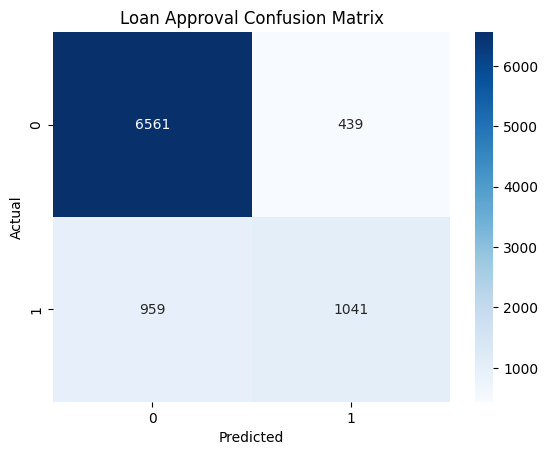

In [99]:
import seaborn as sns

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Loan Approval Confusion Matrix")
plt.show()


In [100]:
y_prob = clf.predict_proba(X_test)[:, 1]


In [101]:
threshold = 0.45   # higher threshold
y_pred_custom = (y_prob >= threshold).astype(int)


In [102]:
from sklearn.metrics import confusion_matrix, classification_report

cm_custom = confusion_matrix(y_test, y_pred_custom)
print(cm_custom)
print(classification_report(y_test, y_pred_custom))


[[6384  616]
 [ 901 1099]]
              precision    recall  f1-score   support

         0.0       0.88      0.91      0.89      7000
         1.0       0.64      0.55      0.59      2000

    accuracy                           0.83      9000
   macro avg       0.76      0.73      0.74      9000
weighted avg       0.82      0.83      0.83      9000



In [103]:
rf_clf_tuned = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_clf_tuned.fit(X_train_dp, y_train_smote)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [104]:
y_prob = clf.predict_proba(X_test)[:, 1]


In [105]:
threshold = 0.45
y_pred_custom = (y_prob >= threshold).astype(int)


In [106]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred_custom)
print("Confusion Matrix:\n", cm)


Confusion Matrix:
 [[6384  616]
 [ 901 1099]]


In [107]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_custom))



Classification Report:

              precision    recall  f1-score   support

         0.0       0.88      0.91      0.89      7000
         1.0       0.64      0.55      0.59      2000

    accuracy                           0.83      9000
   macro avg       0.76      0.73      0.74      9000
weighted avg       0.82      0.83      0.83      9000



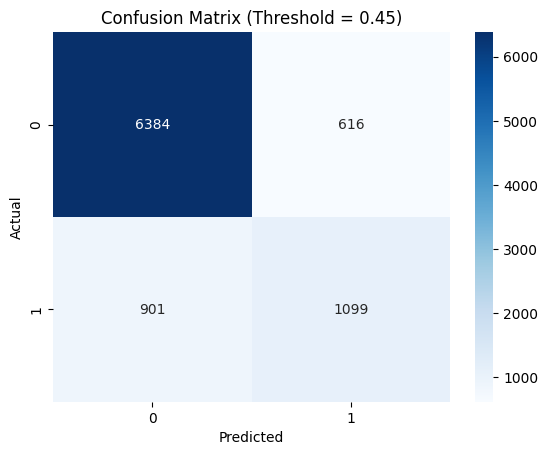

In [108]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix (Threshold = {threshold})")
plt.show()


In [109]:
print("Accuracy:", accuracy_score(y_test, y_pred_custom))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_custom))

cm = confusion_matrix(y_test, y_pred_custom)
TN, FP, FN, TP = cm.ravel()

print("\nConfusion Matrix:")
print(cm)

print("\nFP:", FP)
print("FN:", FN)


Accuracy: 0.8314444444444444

Classification Report:

              precision    recall  f1-score   support

         0.0       0.88      0.91      0.89      7000
         1.0       0.64      0.55      0.59      2000

    accuracy                           0.83      9000
   macro avg       0.76      0.73      0.74      9000
weighted avg       0.82      0.83      0.83      9000


Confusion Matrix:
[[6384  616]
 [ 901 1099]]

FP: 616
FN: 901


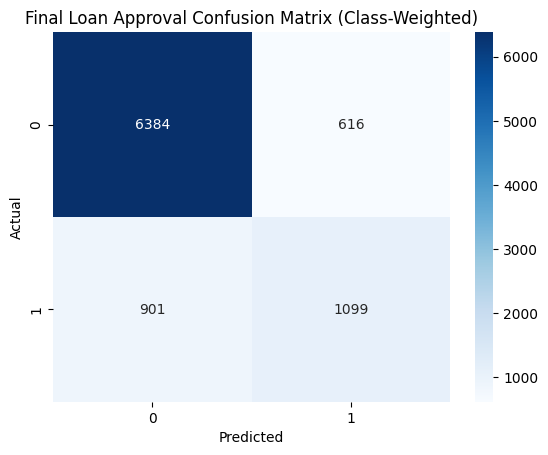

In [110]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final Loan Approval Confusion Matrix (Class-Weighted)")
plt.show()


In [111]:
import joblib
joblib.dump(rf_clf_tuned, "loan_approval_model.pkl")


['loan_approval_model.pkl']

In [112]:
model = joblib.load("loan_approval_model.pkl")


In [113]:
import shap
print(shap.__version__)

0.50.0


In [114]:
import joblib
import shap
import matplotlib.pyplot as plt

clf = joblib.load("loan_approval_model.pkl")


In [115]:
clf_features = [
    "person_age",
    "person_gender",
    "person_education",
    "person_income",
    "person_emp_exp",
    "person_home_ownership",
    "loan_amnt",
    "loan_intent",
    "loan_percent_income",
    "cb_person_cred_hist_length",
    "credit_score",
    "previous_loan_defaults_on_file"
]

clf_data = data[clf_features]


In [116]:
import shap
import numpy as np
import pandas as pd

# small background sample
X_bg = clf_data.sample(100, random_state=42)

# modern explainer
explainer = shap.Explainer(clf, X_bg)

# explain subset
X_sample = clf_data.sample(200, random_state=42)

shap_values = explainer(X_sample)

# global importance
# global importance for approved class (1)
importance = np.abs(shap_values.values[:,:,1]).mean(axis=0)

shap_ranking = pd.Series(
    importance,
    index=X_sample.columns
).sort_values(ascending=False)

print(shap_ranking)

person_emp_exp                    0.043683
person_age                        0.000000
person_education                  0.000000
person_gender                     0.000000
person_income                     0.000000
person_home_ownership             0.000000
loan_amnt                         0.000000
loan_intent                       0.000000
loan_percent_income               0.000000
cb_person_cred_hist_length        0.000000
credit_score                      0.000000
previous_loan_defaults_on_file    0.000000
dtype: float64


C:\Users\prasa\AppData\Local\Temp\ipykernel_20852\1843744381.py:16: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_array, X_shap, show=False)
c:\Users\prasa\Downloads\Loan Approval AI (1)\.venv\Lib\site-packages\shap\plots\_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
c:\Users\prasa\Downloads\Loan Approval AI (1)\.venv\Lib\site-packages\shap\plots\_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this w

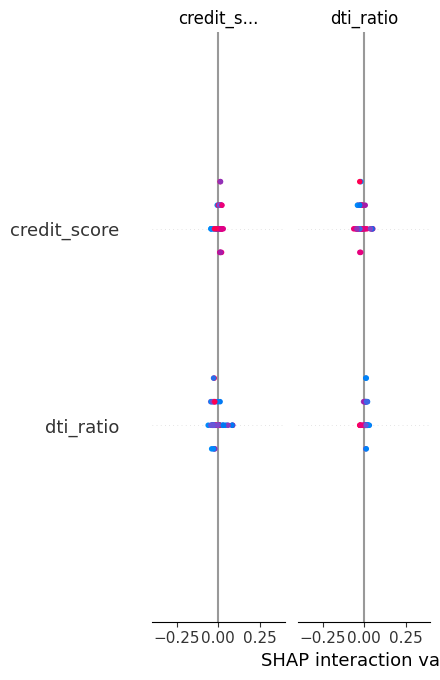

In [117]:
X_shap = X_test_data.sample(50, random_state=42)

explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_shap)

# Handle both list and array outputs safely
if isinstance(shap_values, list):
    shap_array = shap_values[1]   # class 1 (approved)
else:
    shap_array = shap_values

# Ensure feature dimension matches
if shap_array.shape[1] != X_shap.shape[1]:
    shap_array = shap_array[:, :X_shap.shape[1]]

shap.summary_plot(shap_array, X_shap, show=False)
plt.show()

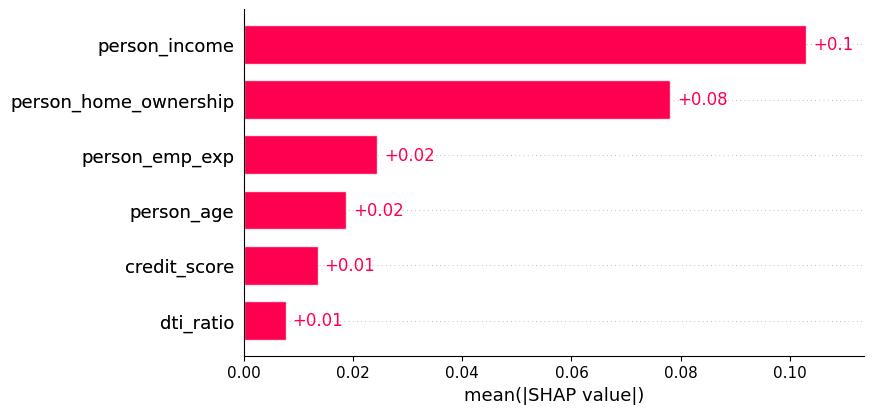

In [118]:
X_shap = X_test_data.sample(50, random_state=42)

masker = shap.maskers.Independent(X_shap)
explainer = shap.Explainer(clf.predict_proba, masker)

shap_values = explainer(X_shap)

# Global feature importance (Approved class)
shap.plots.bar(shap_values[:, :, 1])


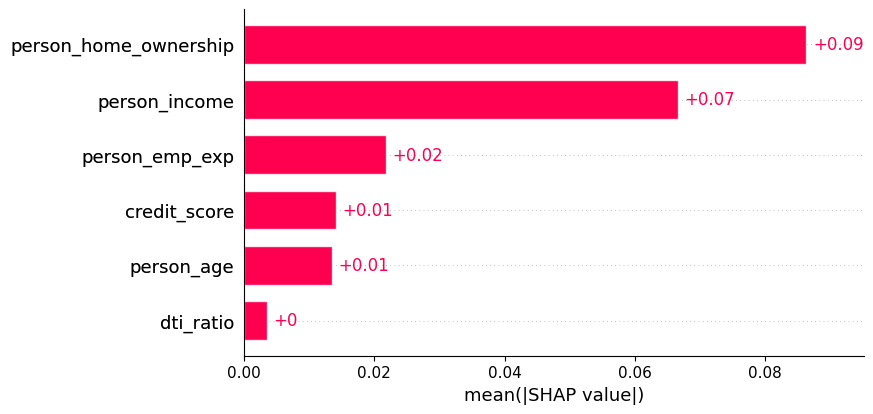

In [119]:
X_one = X_test_data.iloc[[0]]

shap_one = explainer(X_one)

shap.plots.bar(shap_one[:, :, 1])


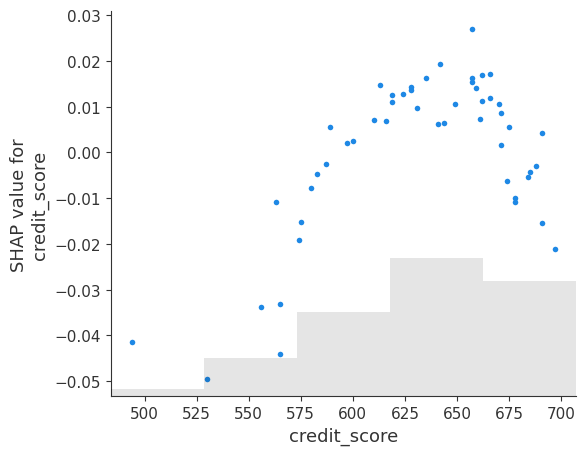

In [120]:
# Scatter plot for credit_score
shap.plots.scatter(
    shap_values[:, "credit_score", 1]
)



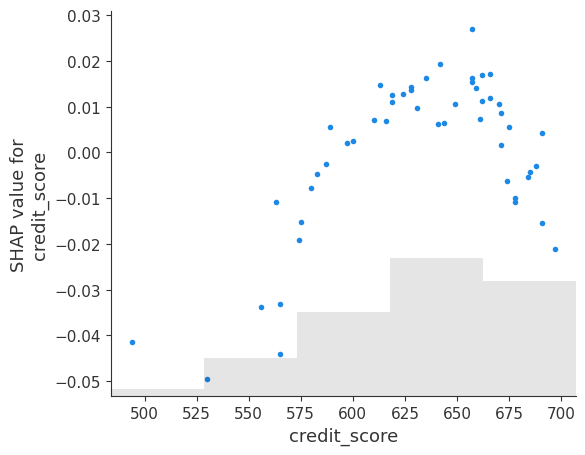

In [121]:
shap.plots.scatter(
    shap_values[:, "credit_score", 1]
)


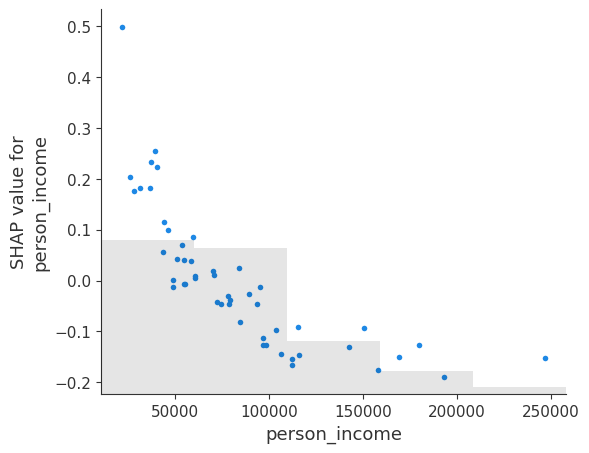

In [122]:
shap.plots.scatter(
    shap_values[:, "person_income", 1]
)


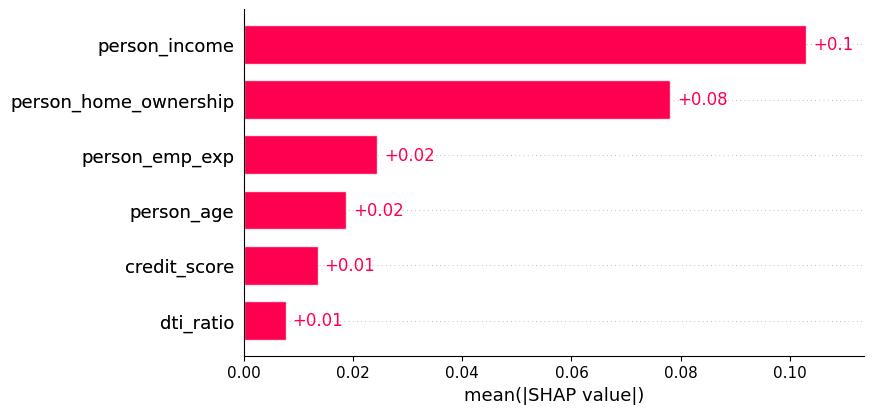

In [123]:
shap.plots.bar(shap_values[:, :, 1])


In [124]:
import pandas as pd
import numpy as np

# Convert SHAP values to DataFrame (class 1 = Approved)
shap_df = pd.DataFrame(
    shap_values[:, :, 1].values,
    columns=X_shap.columns
)

# Mean SHAP value per feature
mean_shap = shap_df.mean().sort_values()

print(mean_shap)


dti_ratio               -4.551914e-17
credit_score            -4.468648e-17
person_emp_exp          -3.760880e-17
person_home_ownership   -3.608225e-17
person_age              -3.171075e-17
person_income           -2.331468e-17
dtype: float64


In [125]:
import numpy as np
import pandas as pd
import shap

def mean_shap_for_n(n):
    X_tmp = X_test_data.sample(n, random_state=42)
    masker = shap.maskers.Independent(X_tmp)
    explainer = shap.Explainer(clf.predict_proba, masker)
    sv = explainer(X_tmp)
    
    shap_df = pd.DataFrame(
        sv[:, :, 1].values,
        columns=X_tmp.columns
    )
    return shap_df.mean()

sizes = [10, 25, 50, 100]
results = {n: mean_shap_for_n(n) for n in sizes}

shap_means = pd.DataFrame(results)
print(shap_means)


ExactExplainer explainer: 101it [00:14,  2.02it/s]                         

                                10            25            50            100
dti_ratio             -7.632783e-18  3.969047e-17 -3.830269e-17 -2.123302e-17
credit_score           1.214306e-18  1.970646e-17 -3.913536e-17 -1.465841e-17
person_income         -1.387779e-18 -1.110223e-18 -2.997602e-17 -2.319325e-17
person_emp_exp        -5.551115e-18  8.604228e-18 -3.982925e-17 -1.817990e-17
person_home_ownership  6.938894e-18  7.216450e-18 -3.275158e-17 -4.329870e-17
person_age            -1.387779e-18  1.228184e-17 -3.164136e-17 -2.359224e-17


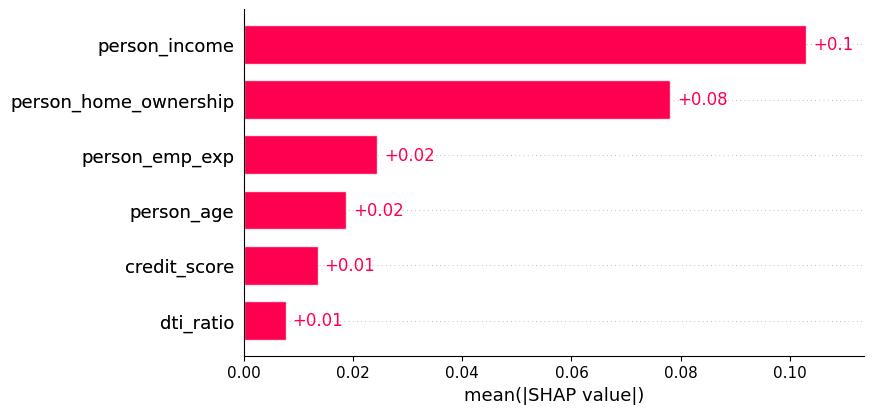

<Figure size 640x480 with 0 Axes>

In [126]:
import matplotlib.pyplot as plt

shap.plots.bar(shap_values[:, :, 1])
plt.savefig("shap_global_importance.png", dpi=300, bbox_inches="tight")
plt.show()


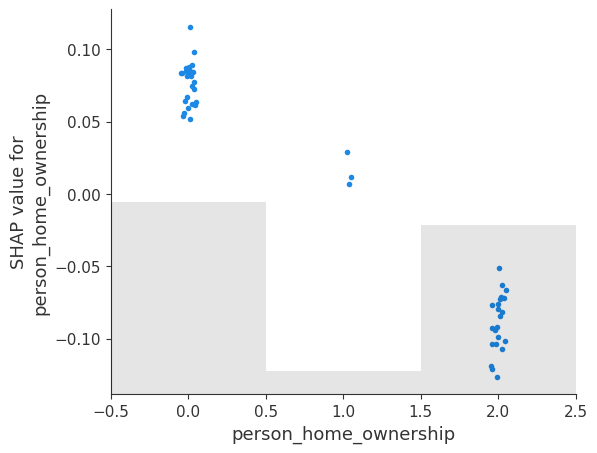

<Figure size 640x480 with 0 Axes>

In [127]:
shap.plots.scatter(
    shap_values[:, "person_home_ownership", 1]
)
plt.savefig("shap_home_ownership_scatter.png", dpi=300, bbox_inches="tight")
plt.show()


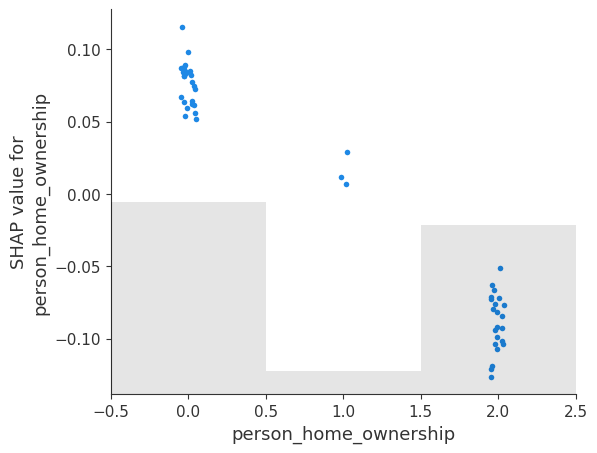

<Figure size 640x480 with 0 Axes>

In [128]:
shap.plots.scatter(
    shap_values[:, "person_home_ownership", 1]
)
plt.savefig("shap_home_ownership_scatter.png", dpi=300, bbox_inches="tight")
plt.show()


In [129]:
# Pick one sample
i = 0
x = X_shap.iloc[[i]]

# Model prediction
proba = clf.predict_proba(x)[0, 1]
pred = clf.predict(x)[0]

print("Predicted class:", pred)
print("Approval probability:", proba)


Predicted class: 0.0
Approval probability: 0.3985833136489274


In [130]:
shap_one = explainer(x)

# Sum of SHAP values (class 1)
shap_sum = shap_one[:, :, 1].values.sum()
print("Sum of SHAP values:", shap_sum)


Sum of SHAP values: -0.01406626701291319


In [131]:
import shap

# Ensure X_test_data exists from earlier split
if 'X_test_data' not in locals():
    X_test_data = X_test.copy()

# Background for SHAP
X_bg = X_test_data.sample(100, random_state=42)

# One customer (row)
X_user = X_test_data.iloc[[0]]

# Create explainer and get SHAP values
masker = shap.maskers.Independent(X_bg)
explainer = shap.Explainer(clf.predict_proba, masker)
shap_user = explainer(X_user)

In [132]:
import pandas as pd
import numpy as np
import shap

# Use TreeExplainer for single sample
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_user)

# Handle different SHAP output formats
# For binary classifiers, shap_values might be list or array
if isinstance(shap_values, list):
    # Multiple classes - get class 1 (approved)
    shap_array = shap_values[1]  # shape: (n_samples, n_features)
    if shap_array.ndim > 1:
        shap_array = shap_array[0]  # Get first sample
else:
    # Single output
    if shap_values.ndim > 1:
        shap_array = shap_values[0]  # First sample
    else:
        shap_array = shap_values

# Ensure 1D array
shap_array = np.asarray(shap_array).flatten()

# Use actual feature names from X_user for consistency
features = list(X_user.columns)
feature_values = X_user.iloc[0].values

# Ensure all arrays have same length
min_len = min(len(shap_array), len(features), len(feature_values))
shap_array = shap_array[:min_len]
features = features[:min_len]
feature_values = feature_values[:min_len]

# Build dataframe
shap_df = pd.DataFrame({
    "feature": features,
    "shap_value": shap_array,
    "feature_value": feature_values
})

# Sort by impact
shap_df = shap_df.sort_values(
    "shap_value",
    key=lambda x: x.abs(),
    ascending=False
)
shap_df

,feature,shap_value,feature_value
5,person_age,-0.104030,25.000000
4,person_home_ownership,0.104030,2.000000
2,person_income,-0.017023,84973.000000
3,person_emp_exp,0.017023,2.000000
0,dti_ratio,0.009369,0.164758
1,credit_score,-0.009369,634.000000


In [133]:
FEATURE_EXPLANATIONS = {
    "credit_score": {
        "positive": "your strong credit history",
        "negative": "your current credit history"
    },
    "loan_percent_income": {
        "positive": "a manageable loan amount relative to your income",
        "negative": "a high loan amount compared to your income"
    },
    "person_income": {
        "positive": "your income level",
        "negative": "your current income level"
    },
    "person_home_ownership": {
        "positive": "stable housing status",
        "negative": "housing stability considerations"
    },
    "previous_loan_defaults_on_file": {
        "positive": "a good repayment record on previous loans",
        "negative": "past loan repayment history"
    },
    "person_emp_exp": {
        "positive": "consistent employment experience",
        "negative": "limited employment experience"
    },
    "loan_int_rate": {
        "positive": "favorable loan terms",
        "negative": "less favorable loan terms"
    }
}


In [134]:
IMPROVEMENT_SUGGESTIONS = {
    "credit_score": "Maintaining timely repayments and reducing outstanding balances may improve future outcomes.",
    "loan_percent_income": "Reducing the loan amount or increasing income can improve eligibility.",
    "person_income": "A higher verified income may improve future loan decisions.",
    "person_home_ownership": "Long-term housing stability may positively influence future applications.",
    "previous_loan_defaults_on_file": "Consistent repayment behavior over time can improve eligibility.",
    "person_emp_exp": "Longer employment continuity may strengthen future applications."
}


In [135]:
def generate_customer_message(
    shap_df,
    prediction,
    approval_probability,
    top_n=3
):
    positives = []
    negatives = []
    suggestions = []

    for _, row in shap_df.head(top_n).iterrows():
        feature = row["feature"]
        shap_val = row["shap_value"]

        if feature not in FEATURE_EXPLANATIONS:
            continue

        if shap_val > 0:
            positives.append(FEATURE_EXPLANATIONS[feature]["positive"])
        else:
            negatives.append(FEATURE_EXPLANATIONS[feature]["negative"])
            if feature in IMPROVEMENT_SUGGESTIONS:
                suggestions.append(IMPROVEMENT_SUGGESTIONS[feature])

    # --- Decision header ---
    if prediction == 1:
        header = "✅ **Loan Decision: Approved**"
        summary = "Your loan application was approved after reviewing multiple financial factors."
    else:
        header = "❌ **Loan Decision: Not Approved**"
        summary = "Your loan application could not be approved at this time after reviewing multiple financial factors."

    # --- Explanation body ---
    message = header + "\n\n" + summary + "\n\n"

    if positives:
        message += "### Positive factors\n"
        for p in positives:
            message += f"- {p.capitalize()}\n"

    if negatives:
        message += "\n### Factors that limited the decision\n"
        for n in negatives:
            message += f"- {n.capitalize()}\n"

    if suggestions:
        message += "\n### How you may improve future applications\n"
        for s in set(suggestions):
            message += f"- {s}\n"

    return message


In [136]:
prediction = clf.predict(X_user)[0]
approval_prob = clf.predict_proba(X_user)[0, 1]

customer_message = generate_customer_message(
    shap_df=shap_df,
    prediction=prediction,
    approval_probability=approval_prob
)

print(customer_message)


❌ **Loan Decision: Not Approved**

Your loan application could not be approved at this time after reviewing multiple financial factors.

### Positive factors
- Stable housing status

### Factors that limited the decision
- Your current income level

### How you may improve future applications
- A higher verified income may improve future loan decisions.

